# Comparing ERA5 sources - CDS vs NCAR

`atlite` offers two sources for the ERA5 dataset - CDS and NCAR. ERA5 is natively hosted on the Copernicus Data Store, which offers many convenient options for server-side processing of the raw ERA5 data. However, it can only serve 400 simultaneous requests, so you often have to wait for hours in order to download data, which can be annoying and difficult to debug. CDS also requires setting up an account and managing API keys for authentication.

The National Center for Atmospheric Research hosts a mirror of ERA5. They do not have a queue, and do not require authentication. However, they offer very limited server-side processing, which means you need to download a bit more data, and do more processing on device. Some of the CDS server-side processing is difficult to mimic locally, so there may be numerical differences between the two datasets if you decide to use non-default resolutions.

This table summarises the differences between the two datasets:

|                      | CDS                  | NCAR          |
|----------------------|----------------------|---------------|
| atlite API           | same                 | same          |
| authentication/setup | API + accept license | none          |
| download queue       | 5min-8hrs            | none          |
| cutout size          | 1x                   | 1x            |
| download size        | 1x                   | ~1.5x         |
| data storage grid    | parameter-dependent  | 0.25 deg. grid |
| results at 0.25 deg. grid    | reference | identical |
| results at irregular grids    | reference |  up to 5% difference |



> **So which source should I use?** For very large cutouts (e.g. continents larger than Europe), for workflows that already used CDS, and when you require data at resolution that is not a multiple of the default 0.25/0.25 deg. grid, use CDS. For everything else, NCAR is more convenient.

In this example we will demonstrate how to use the NCAR mirror of the ERA5 dataset within `atlite` and show under what circumstances there may be numerical differences between them. For a more detailed explanation on how to build cutouts, follow [this notebook](https://atlite.readthedocs.io/en/master/examples/create_cutout.html).

We start with the setup:

In [13]:
import logging
from pathlib import Path

import numpy as np
import xarray as xr

import atlite

logging.basicConfig(level=logging.INFO)

Let's download cutouts from both sources:

In [14]:
TIME = "2013-01-01"
BOUNDS = (-4, 56, 1.5, 62)
CACHE = Path(".cache")
CACHE.mkdir(exist_ok=True)

cutout_CDS = atlite.Cutout(
    path=CACHE / "era5-cds-native.nc",
    module="era5",
    bounds=BOUNDS,
    time=TIME,
)
cutout_CDS.prepare()

<Cutout "era5-cds-native">
 x = -4.00 ⟷ 1.50, dx = 0.25
 y = 56.00 ⟷ 62.00, dy = 0.25
 time = 2013-01-01 ⟷ 2013-01-01, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

In [15]:
cutout_NCAR = atlite.Cutout(
    path=CACHE / "era5-ncar-native.nc",
    module="era5-ncar",
    bounds=BOUNDS,
    time=TIME,
)
cutout_NCAR.prepare(tmpdir=CACHE)

<Cutout "era5-ncar-native">
 x = -4.00 ⟷ 1.50, dx = 0.25
 y = 56.00 ⟷ 62.00, dy = 0.25
 time = 2013-01-01 ⟷ 2013-01-01, dt = h
 module = era5-ncar
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

As you can see, the API for both datasets is identical. The only change needed is replacing `module="era5"` with `module="era5-ncar"`. NCAR provides the same atlite-facing functionality. Now let's compare the data at the native grid.

In [16]:
common_vars = set(cutout_CDS.data.data_vars) & set(cutout_NCAR.data.data_vars)

print(
    "Both cutouts have the same features:",
    common_vars == set(cutout_CDS.data.data_vars),
)

try:
    xr.testing.assert_allclose(
        cutout_CDS.data[common_vars], cutout_NCAR.data[common_vars], atol=1e-4
    )
    print("Data in both sources matches within tolerance")
except Exception:
    print("Data in both features is NOT identical")

Both cutouts have the same features: True
Data in both sources matches within tolerance


**This close agreement is expected when pulling data at the default resolution of 0.25/0.25 deg. used by atlite, and also at its multiples (e.g. 0.5/0.5 deg.)**

The results will diverge slightly when you need to change the resolution. CDS uses its [own interpolation library](https://confluence.ecmwf.int/display/UDOC/MARS+interpolation+with+MIR) to derive results at non-default resolutions. For NCAR data, we simply do linear interpolation from the 0.25 deg. grid. Let's see what the differences are.

> Note: using irregular grids as we do below is generally not recommended, see the CDS documentation [here](https://confluence.ecmwf.int/display/CKB/ERA5%3A+What+is+the+spatial+reference). We only do this for illustration purposes.

The snippet below downloads data at another resolution and plots maximum differences between CDS and NCAR for the _worst offender_ variables.

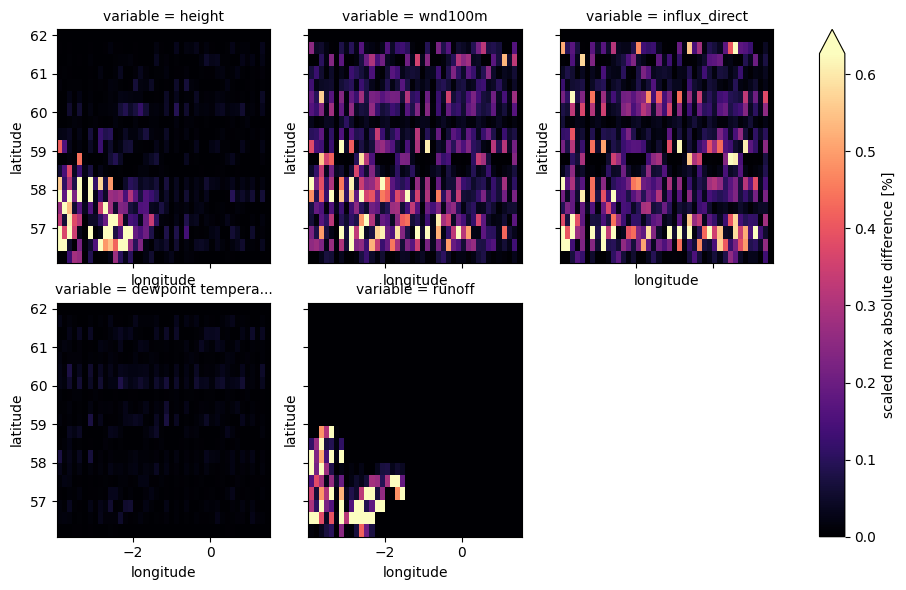

In [18]:
INTERPOLATED_DX = 0.132
INTERPOLATED_DY = 0.32
WORST_DIFF_VARS = [
    "height",
    "wnd100m",
    "influx_direct",
    "dewpoint temperature",
    "runoff",
]

cutout_interpolated_CDS = atlite.Cutout(
    path=CACHE / "era5-cds-interpolated.nc",
    module="era5",
    bounds=BOUNDS,
    time=TIME,
    dx=INTERPOLATED_DX,
    dy=INTERPOLATED_DY,
)
cutout_interpolated_CDS.prepare()

cutout_interpolated_NCAR = atlite.Cutout(
    path=CACHE / "era5-ncar-interpolated.nc",
    module="era5-ncar",
    bounds=BOUNDS,
    time=TIME,
    dx=INTERPOLATED_DX,
    dy=INTERPOLATED_DY,
)
cutout_interpolated_NCAR.prepare(tmpdir=CACHE)


def scaled_max_abs_diff(reference, candidate, eps=1e-12):
    diff = np.abs(candidate - reference)
    scale = float(np.maximum(np.abs(reference), np.abs(candidate)).max(skipna=True))
    if scale < eps:
        scale = 1.0
    reduce_dims = [dim for dim in diff.dims if dim not in {"x", "y"}]
    diff_map = diff.max(dim=reduce_dims, skipna=True) if reduce_dims else diff
    return 100 * diff_map.fillna(0) / scale


diff_maps = [
    scaled_max_abs_diff(
        cutout_interpolated_CDS.data[var],
        cutout_interpolated_NCAR.data[var],
    ).assign_coords(variable=var)
    for var in WORST_DIFF_VARS
]

relative_max_diff = xr.concat(diff_maps, dim="variable").rename(
    "scaled max absolute difference [%]"
)

grid = relative_max_diff.plot.pcolormesh(
    x="x",
    y="y",
    col="variable",
    col_wrap=3,
    cmap="magma",
    robust=True,
    cbar_kwargs={"label": "scaled max absolute difference [%]"},
)

for ax in grid.axs.flat:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

Differences are pretty small, and become less relevant when we calculate actual renewable potentials. But they get much worse around sharp discontinuities such as coasts or forest boundaries. Below you can see differences in wind and solar capacity factors calculated for Europe at different grids (clipped at 95th percentile). At 0.5/0.5 deg there is no difference. At other resolutions, the differences are worst around discontinuities.

- 0.5/0.5 deg:
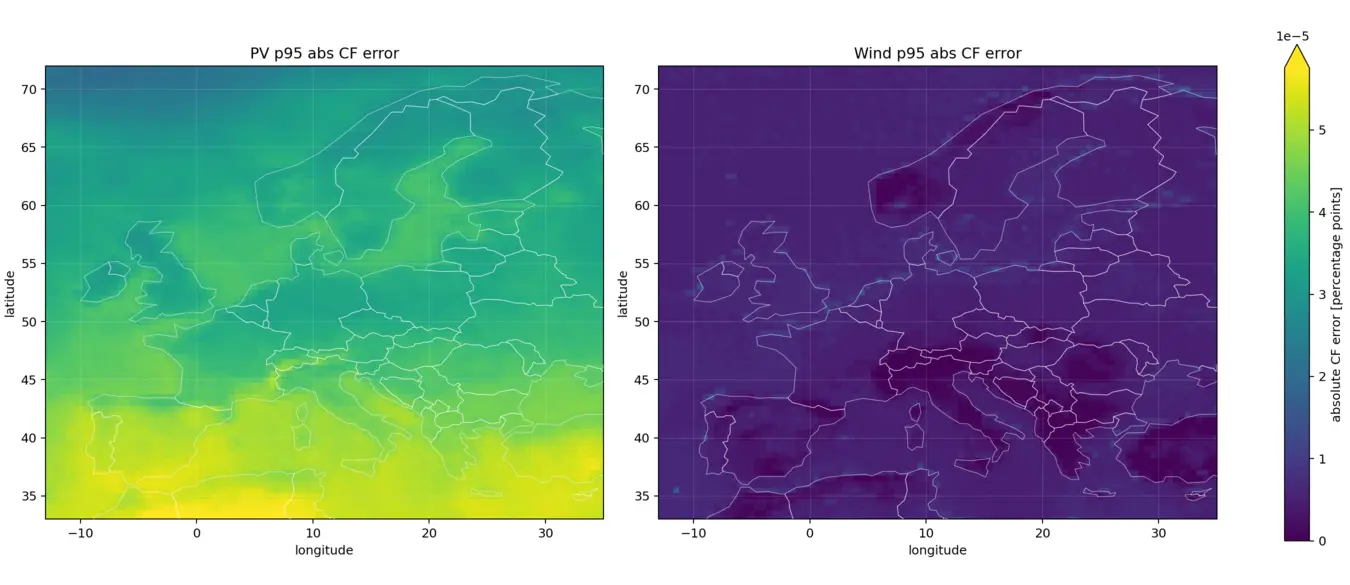
- 0.3/0.3 deg:
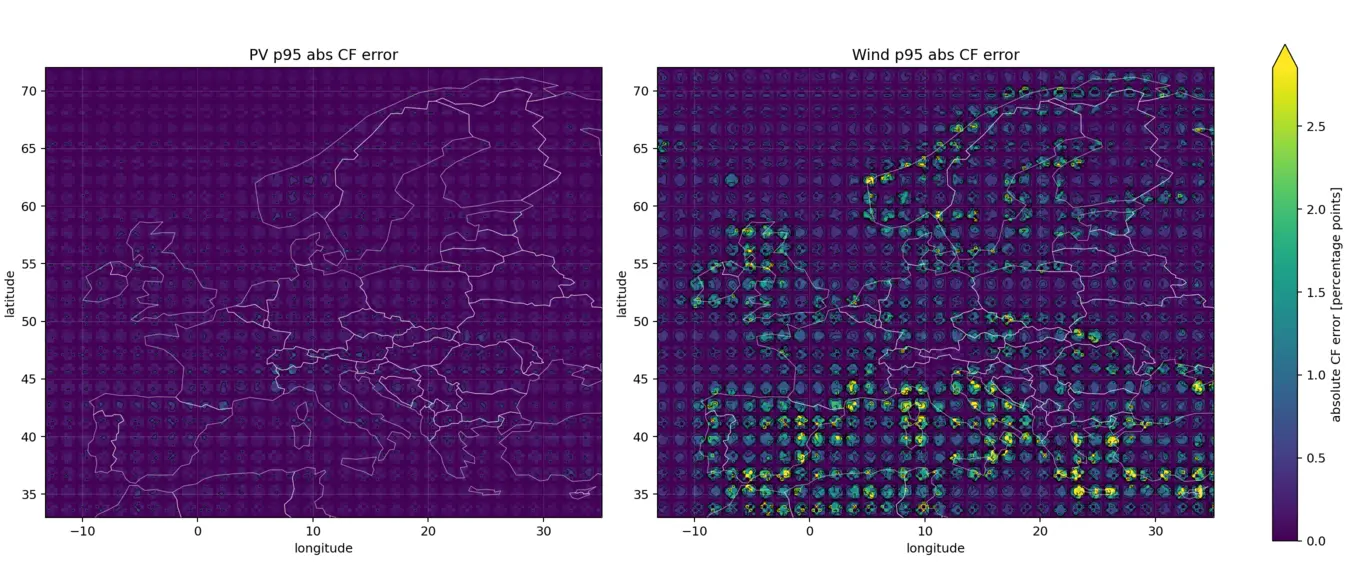
- 0.132/0.32 deg:
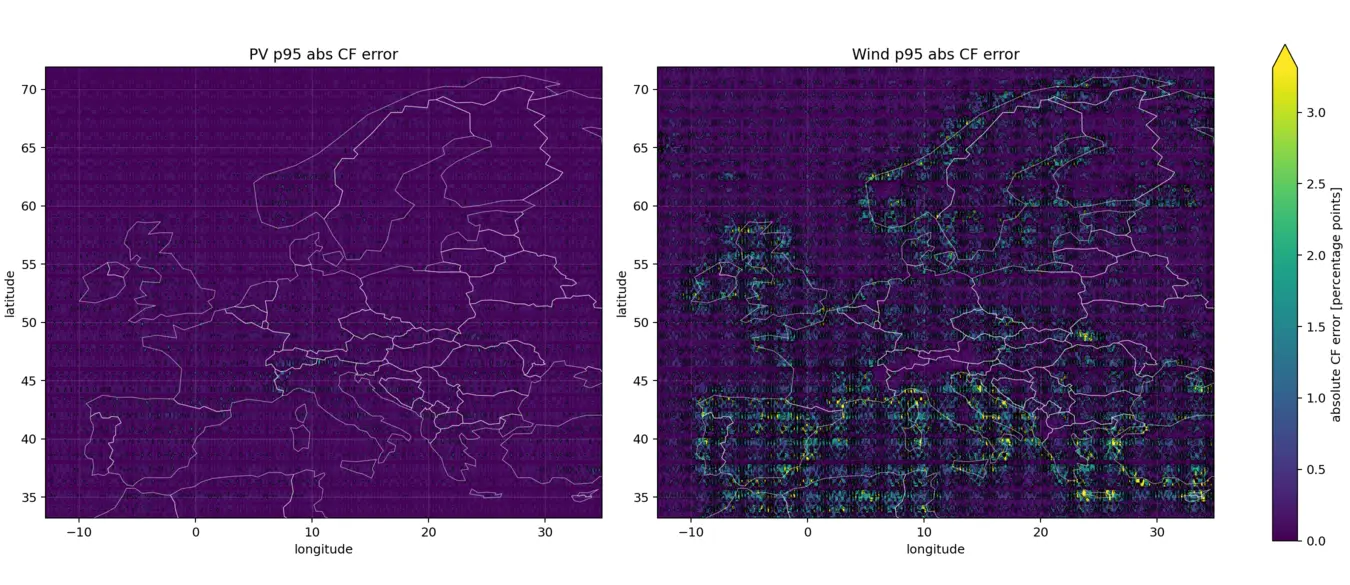

> **The conclusion once again:** For very large cutouts (e.g. continents larger than Europe), for workflows that already used CDS, and when you require data at resolution that is not a multiple of 0.25/0.25 deg. grid, use CDS. For everything else, NCAR is more convenient. And the change from one to another is a single line of code.